In [4]:
#Libraray Import
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, train_test_split, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,auc
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import time

In [5]:
from google.colab import files

uploaded = files.upload()


Saving medical_data_clean.csv to medical_data_clean.csv


In [6]:
# Assuming 'medical_data_clean.csv' was the uploaded file
df = pd.read_csv('medical_data_clean.csv')
display(df.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,...,S5_T3,S6_T3,Age,Sex,Smoking,LC_stage,LC_type,Group,Group_name,lscm
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,...,8.850000e-07,7.660000e-07,50,1,1,3,0,1,LC group,4
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,...,1.160000e-06,9.310000e-07,68,0,0,4,1,1,LC group,3
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,...,4.080000e-06,3.070000e-06,70,1,1,1,1,1,LC group,4
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,...,1.420000e-06,1.070000e-06,66,0,0,4,1,1,LC group,3
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,...,1.400000e-06,1.190000e-06,69,1,1,1,1,1,LC group,4


In [7]:
#Defining the X and Y variables
X = df.drop(columns=["Group","LC_stage","LC_type","lscm","Age","Sex","Smoking","Group_name"])
y = df["Group"]
display(X.head())
display(y.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,S5_T2,S6_T2,S1_T3,S2_T3,S3_T3,S4_T3,S5_T3,S6_T3
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,0.000002,1.500000e-06,5.560000e-07,2.720000e-07,0.000035,0.000004,8.850000e-07,7.660000e-07
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,0.000001,8.760000e-07,2.110000e-07,1.750000e-07,0.000035,0.000004,1.160000e-06,9.310000e-07
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,0.000003,2.750000e-06,6.980000e-07,5.250000e-07,0.000119,0.000013,4.080000e-06,3.070000e-06
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,0.000001,9.480000e-07,2.760000e-07,3.300000e-07,0.000038,0.000005,1.420000e-06,1.070000e-06
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,0.000001,1.170000e-06,3.210000e-07,3.700000e-07,0.000044,0.000006,1.400000e-06,1.190000e-06


,Group
0,1
1,1
2,1
3,1
4,1


XGBoost Model

In [8]:
MODEL_SPECS = {
    "XGBoost": {
        "estimator": lambda random_state: XGBClassifier(
            random_state=random_state, eval_metric="logloss"
        ),
        "param_distributions": {
            "model__n_estimators":     [50, 75, 100],
            "model__max_depth":        [2, 3, 4, 5],
            "model__learning_rate":    [0.05, 0.1],
            "model__gamma":            [0.0, 0.1],
            "model__subsample":        [0.7, 0.8, 0.9],
            "model__colsample_bytree": [0.7, 0.8, 0.9],
            "model__reg_lambda":       [1, 1.5, 2],
        },
        "n_iter": 50,
    },
}

In [9]:
def build_pipeline(estimator, random_state, use_smote):
    steps = [("scaler", RobustScaler())]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=random_state)))
    steps.append(("model", estimator))
    return ImbPipeline(steps=steps)

In [10]:
# 3. Nested CV — corrected pipeline
def nested_cv_corrected(
    model_name, X, y,
    n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=True,
):
    spec = MODEL_SPECS[model_name]

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    X_values = X.values
    y_values = y.values if isinstance(y, pd.Series) else np.asarray(y)

    outer_skf = StratifiedKFold(n_splits=n_outer_splits, shuffle=True,
                                 random_state=random_state)

    results = {"roc_auc": [], "accuracy": [], "sensitivity": [], "specificity": [],
               "best_params": []}

    print(f"\n{'='*60}\n{model_name}: Nested CV ({n_outer_splits}x{n_inner_splits}, corrected pipeline)\n{'='*60}")
    total_start = time.time()

    for outer_fold, (train_idx, test_idx) in enumerate(
            outer_skf.split(X_values, y_values), 1):

        fold_start = time.time()

        # ---- Step 1: split outer train / outer test first, nothing else touches test yet
        X_train_outer, X_test_outer = X_values[train_idx], X_values[test_idx]
        y_train_outer, y_test_outer = y_values[train_idx], y_values[test_idx]

        # ---- Step 2: inner 3-fold CV over the OUTER-TRAINING data only.
        # RandomizedSearchCV clones and re-fits `pipe` on each inner-training
        # split — i.e. RobustScaler.fit_transform + SMOTE.fit_resample are
        # each recomputed from scratch on that inner-training fold only,
        # and only .transform() (no SMOTE) is applied to the inner-validation
        # fold. This is exactly the top branch of your diagram.
        inner_skf = StratifiedKFold(n_splits=n_inner_splits, shuffle=True,
                                     random_state=random_state)

        pipe = build_pipeline(spec["estimator"](random_state), random_state, use_smote)

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=spec["param_distributions"],
            n_iter=spec["n_iter"],
            cv=inner_skf,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=random_state,
            verbose=0,
            refit=True,   # <-- after search, refits the WINNING pipeline
                          #     (scaler + SMOTE + model) on the COMPLETE
                          #     outer-training partition. This is exactly
                          #     the bottom branch of your diagram.
        )
        search.fit(X_train_outer, y_train_outer)

        best_pipeline = search.best_estimator_   # scaler+SMOTE+model, refit on full outer-train
        best_params   = search.best_params_

        # ---- Step 3: evaluate ONCE on the untouched outer test fold.
        # best_pipeline.predict()/.predict_proba() apply scaler.transform()
        # (fitted on outer-train) and skip SMOTE entirely (SMOTE never runs
        # outside .fit()) — so the outer test fold is genuinely untouched
        # by both scaling-fit and resampling.
        y_pred = best_pipeline.predict(X_test_outer)
        y_prob = best_pipeline.predict_proba(X_test_outer)[:, 1]

        cm = confusion_matrix(y_test_outer, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        results["roc_auc"].append(roc_auc_score(y_test_outer, y_prob))
        results["accuracy"].append(accuracy_score(y_test_outer, y_pred))
        results["sensitivity"].append(tp / (tp + fn) if (tp + fn) else np.nan)
        results["specificity"].append(tn / (tn + fp) if (tn + fp) else np.nan)
        results["best_params"].append(best_params)

        print(f"  Fold {outer_fold}: ROC-AUC={results['roc_auc'][-1]:.4f}  "
              f"Acc={results['accuracy'][-1]:.4f}  "
              f"Sens={results['sensitivity'][-1]:.4f}  "
              f"Spec={results['specificity'][-1]:.4f}  "
              f"({time.time()-fold_start:.1f}s)  params={best_params}")

    print(f"\n{model_name} — FINAL (mean ± std across {n_outer_splits} folds):")
    for metric in ["roc_auc", "accuracy", "sensitivity", "specificity"]:
        m, sd = np.mean(results[metric]), np.std(results[metric])
        print(f"  {metric:12s}: {m:.4f} ± {sd:.4f}")
    print(f"  Total time: {time.time()-total_start:.1f}s")

    return results

SENSORS ONLY

In [11]:
# with smote
nested_cv_corrected(model_name='XGBoost', X=X, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= True)




XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=1.0000  Acc=1.0000  Sens=1.0000  Spec=1.0000  (8.1s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 2: ROC-AUC=0.9720  Acc=0.9167  Sens=0.9231  Spec=0.9091  (3.8s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 50, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
  Fold 3: ROC-AUC=0.9650  Acc=0.9583  Sens=0.9231  Spec=1.0000  (5.6s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.8}
  Fold 4: ROC-AUC=0.8769  Acc=0.9130  Sens=0.8462  Spec=1.0000  (3.9s)  params={'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model__

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(0.965034965034965),
  np.float64(0.8769230769230769),
  np.float64(0.9615384615384615)],
 'accuracy': [1.0,
  0.9166666666666666,
  0.9583333333333334,
  0.9130434782608695,
  0.9130434782608695],
 'sensitivity': [np.float64(1.0),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 'best_params': [{'model__subsample': 0.9,
   'model__reg_lambda': 1.5,
   'model__n_estimators': 100,
   'model__max_depth': 3,
   'model__learning_rate': 0.05,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.9},
  {'model__subsample': 0.9,
   'model__reg_lambda': 2,
   'model__n_estimators': 50,
   'model__max_depth': 5,
   'model__learning_rate': 0.1,
   'model__gamma': 0.1,
   'model__colsample_bytree': 0.8},
  {'m

In [12]:
#without smote
nested_cv_corrected(model_name='XGBoost', X=X, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= False)


XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=1.0000  Acc=1.0000  Sens=1.0000  Spec=1.0000  (4.2s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 2: ROC-AUC=0.9720  Acc=0.9167  Sens=0.9231  Spec=0.9091  (4.6s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 3: ROC-AUC=0.9720  Acc=0.9583  Sens=0.9231  Spec=1.0000  (3.5s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.8}
  Fold 4: ROC-AUC=0.8769  Acc=0.9130  Sens=0.8462  Spec=1.0000  (3.4s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model_

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(0.972027972027972),
  np.float64(0.8769230769230769),
  np.float64(0.9461538461538461)],
 'accuracy': [1.0,
  0.9166666666666666,
  0.9583333333333334,
  0.9130434782608695,
  0.9130434782608695],
 'sensitivity': [np.float64(1.0),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 'best_params': [{'model__subsample': 0.9,
   'model__reg_lambda': 2,
   'model__n_estimators': 100,
   'model__max_depth': 4,
   'model__learning_rate': 0.1,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.9},
  {'model__subsample': 0.9,
   'model__reg_lambda': 1.5,
   'model__n_estimators': 100,
   'model__max_depth': 3,
   'model__learning_rate': 0.05,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.9},
  {'

DEMOGRAPHICS ONLY

In [13]:
#For demographics only
X1 = df[['Age','Sex','Smoking']]

In [14]:
#with smote
nested_cv_corrected(model_name='XGBoost', X=X1, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= True)


XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=0.8112  Acc=0.7917  Sens=0.7692  Spec=0.8182  (3.2s)  params={'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
  Fold 2: ROC-AUC=0.7867  Acc=0.7500  Sens=0.8462  Spec=0.6364  (2.9s)  params={'model__subsample': 0.7, 'model__reg_lambda': 1.5, 'model__n_estimators': 75, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
  Fold 3: ROC-AUC=0.7622  Acc=0.6667  Sens=0.9231  Spec=0.3636  (2.9s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 50, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
  Fold 4: ROC-AUC=0.6731  Acc=0.5652  Sens=0.6154  Spec=0.5000  (3.6s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__m

{'roc_auc': [np.float64(0.8111888111888113),
  np.float64(0.7867132867132867),
  np.float64(0.7622377622377623),
  np.float64(0.6730769230769231),
  np.float64(0.7500000000000001)],
 'accuracy': [0.7916666666666666,
  0.75,
  0.6666666666666666,
  0.5652173913043478,
  0.6086956521739131],
 'sensitivity': [np.float64(0.7692307692307693),
  np.float64(0.8461538461538461),
  np.float64(0.9230769230769231),
  np.float64(0.6153846153846154),
  np.float64(0.38461538461538464)],
 'specificity': [np.float64(0.8181818181818182),
  np.float64(0.6363636363636364),
  np.float64(0.36363636363636365),
  np.float64(0.5),
  np.float64(0.9)],
 'best_params': [{'model__subsample': 0.7,
   'model__reg_lambda': 2,
   'model__n_estimators': 100,
   'model__max_depth': 2,
   'model__learning_rate': 0.05,
   'model__gamma': 0.1,
   'model__colsample_bytree': 0.8},
  {'model__subsample': 0.7,
   'model__reg_lambda': 1.5,
   'model__n_estimators': 75,
   'model__max_depth': 3,
   'model__learning_rate': 0.1,


In [15]:
#without smote
nested_cv_corrected(model_name='XGBoost', X=X1, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= False)


XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=0.8252  Acc=0.7500  Sens=0.8462  Spec=0.6364  (2.6s)  params={'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.7}
  Fold 2: ROC-AUC=0.8531  Acc=0.7917  Sens=1.0000  Spec=0.5455  (2.6s)  params={'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__n_estimators': 75, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.8}
  Fold 3: ROC-AUC=0.7622  Acc=0.6667  Sens=0.9231  Spec=0.3636  (2.6s)  params={'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__n_estimators': 75, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.8}
  Fold 4: ROC-AUC=0.6731  Acc=0.5652  Sens=0.6154  Spec=0.5000  (4.2s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__ma

{'roc_auc': [np.float64(0.8251748251748252),
  np.float64(0.8531468531468532),
  np.float64(0.7622377622377623),
  np.float64(0.6730769230769231),
  np.float64(0.7730769230769231)],
 'accuracy': [0.75,
  0.7916666666666666,
  0.6666666666666666,
  0.5652173913043478,
  0.6956521739130435],
 'sensitivity': [np.float64(0.8461538461538461),
  np.float64(1.0),
  np.float64(0.9230769230769231),
  np.float64(0.6153846153846154),
  np.float64(0.6153846153846154)],
 'specificity': [np.float64(0.6363636363636364),
  np.float64(0.5454545454545454),
  np.float64(0.36363636363636365),
  np.float64(0.5),
  np.float64(0.8)],
 'best_params': [{'model__subsample': 0.7,
   'model__reg_lambda': 2,
   'model__n_estimators': 100,
   'model__max_depth': 4,
   'model__learning_rate': 0.05,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.7},
  {'model__subsample': 0.7,
   'model__reg_lambda': 2,
   'model__n_estimators': 75,
   'model__max_depth': 2,
   'model__learning_rate': 0.05,
   'model__gamma'

SENSORS + DEMOGRAPHICS

In [16]:
#For sensor+ demographics
X2 = df.drop(columns=["Group","LC_stage","LC_type","lscm","Group_name"])
display(X2.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,...,S6_T2,S1_T3,S2_T3,S3_T3,S4_T3,S5_T3,S6_T3,Age,Sex,Smoking
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,...,1.500000e-06,5.560000e-07,2.720000e-07,0.000035,0.000004,8.850000e-07,7.660000e-07,50,1,1
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,...,8.760000e-07,2.110000e-07,1.750000e-07,0.000035,0.000004,1.160000e-06,9.310000e-07,68,0,0
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,...,2.750000e-06,6.980000e-07,5.250000e-07,0.000119,0.000013,4.080000e-06,3.070000e-06,70,1,1
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,...,9.480000e-07,2.760000e-07,3.300000e-07,0.000038,0.000005,1.420000e-06,1.070000e-06,66,0,0
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,...,1.170000e-06,3.210000e-07,3.700000e-07,0.000044,0.000006,1.400000e-06,1.190000e-06,69,1,1


In [17]:
#with smote
nested_cv_corrected(model_name='XGBoost', X=X2, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= True)


XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=1.0000  Acc=0.9583  Sens=0.9231  Spec=1.0000  (4.0s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 2: ROC-AUC=0.9720  Acc=0.9167  Sens=0.9231  Spec=0.9091  (3.9s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 3: ROC-AUC=1.0000  Acc=0.9583  Sens=0.9231  Spec=1.0000  (5.7s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__n_estimators': 75, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 4: ROC-AUC=0.8615  Acc=0.9130  Sens=0.8462  Spec=1.0000  (3.8s)  params={'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__n_estimators': 50, 'model__

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(1.0),
  np.float64(0.8615384615384615),
  np.float64(0.9307692307692308)],
 'accuracy': [0.9583333333333334,
  0.9166666666666666,
  0.9583333333333334,
  0.9130434782608695,
  0.9130434782608695],
 'sensitivity': [np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 'best_params': [{'model__subsample': 0.9,
   'model__reg_lambda': 2,
   'model__n_estimators': 100,
   'model__max_depth': 4,
   'model__learning_rate': 0.1,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.9},
  {'model__subsample': 0.9,
   'model__reg_lambda': 1.5,
   'model__n_estimators': 100,
   'model__max_depth': 3,
   'model__learning_rate': 0.05,
   'model__gamma': 0.0,
   'model__colsample_byt

In [18]:
#without smote
nested_cv_corrected(model_name='XGBoost', X=X2, y=y, n_inner_splits=3, n_outer_splits=5, random_state=42, use_smote= False)


XGBoost: Nested CV (5x3, corrected pipeline)
  Fold 1: ROC-AUC=1.0000  Acc=1.0000  Sens=1.0000  Spec=1.0000  (5.3s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 2: ROC-AUC=0.9580  Acc=0.8750  Sens=0.8462  Spec=0.9091  (3.5s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 50, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.9}
  Fold 3: ROC-AUC=0.9790  Acc=0.9583  Sens=0.9231  Spec=1.0000  (3.5s)  params={'model__subsample': 0.7, 'model__reg_lambda': 1.5, 'model__n_estimators': 75, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
  Fold 4: ROC-AUC=0.8769  Acc=0.9130  Sens=0.8462  Spec=1.0000  (4.9s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model__ma

{'roc_auc': [np.float64(1.0),
  np.float64(0.958041958041958),
  np.float64(0.979020979020979),
  np.float64(0.876923076923077),
  np.float64(0.9538461538461538)],
 'accuracy': [1.0,
  0.875,
  0.9583333333333334,
  0.9130434782608695,
  0.8695652173913043],
 'sensitivity': [np.float64(1.0),
  np.float64(0.8461538461538461),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9)],
 'best_params': [{'model__subsample': 0.9,
   'model__reg_lambda': 2,
   'model__n_estimators': 100,
   'model__max_depth': 4,
   'model__learning_rate': 0.1,
   'model__gamma': 0.0,
   'model__colsample_bytree': 0.9},
  {'model__subsample': 0.9,
   'model__reg_lambda': 1,
   'model__n_estimators': 50,
   'model__max_depth': 5,
   'model__learning_rate': 0.05,
   'model__gamma': 0.1,
   'model__colsample_bytree': 0.9},
  {'model__subsample'

Running Model 1: Sensors only (with SMOTE) …

XGBoost: Nested CV (5x3)
  Fold 1: ROC-AUC=1.0000  Acc=1.0000  Sens=1.0000  Spec=1.0000  (12.0s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.9}
  Fold 2: ROC-AUC=0.9720  Acc=0.9167  Sens=0.9231  Spec=0.9091  (3.8s)  params={'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__n_estimators': 50, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
  Fold 3: ROC-AUC=0.9650  Acc=0.9583  Sens=0.9231  Spec=1.0000  (3.9s)  params={'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.8}
  Fold 4: ROC-AUC=0.8769  Acc=0.9130  Sens=0.8462  Spec=1.0000  (5.5s)  params={'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__n_

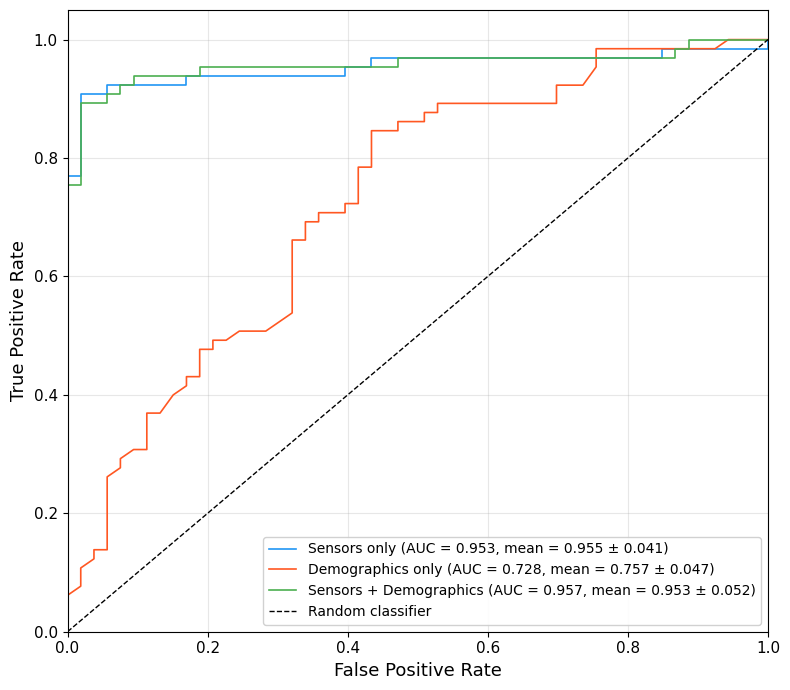

In [21]:
def nested_cv_corrected_with_roc(
    model_name, X, y,
    n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=True,
):
    spec = MODEL_SPECS[model_name]

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    X_values = X.values
    y_values = y.values if isinstance(y, pd.Series) else np.asarray(y)

    outer_skf = StratifiedKFold(n_splits=n_outer_splits, shuffle=True,
                                 random_state=random_state)

    results = {"roc_auc": [], "accuracy": [], "sensitivity": [], "specificity": [],
               "best_params": []}
    all_y_test, all_y_prob = [], []          # <-- NEW: collect real OOF predictions

    print(f"\n{'='*60}\n{model_name}: Nested CV ({n_outer_splits}x{n_inner_splits})\n{'='*60}")
    total_start = time.time()

    for outer_fold, (train_idx, test_idx) in enumerate(
            outer_skf.split(X_values, y_values), 1):

        fold_start = time.time()
        X_train_outer, X_test_outer = X_values[train_idx], X_values[test_idx]
        y_train_outer, y_test_outer = y_values[train_idx], y_values[test_idx]

        inner_skf = StratifiedKFold(n_splits=n_inner_splits, shuffle=True,
                                     random_state=random_state)

        pipe = build_pipeline(spec["estimator"](random_state), random_state, use_smote)

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=spec["param_distributions"],
            n_iter=spec["n_iter"],
            cv=inner_skf,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=random_state,
            verbose=0,
            refit=True,
        )
        search.fit(X_train_outer, y_train_outer)

        best_pipeline = search.best_estimator_
        best_params   = search.best_params_

        y_pred = best_pipeline.predict(X_test_outer)
        y_prob = best_pipeline.predict_proba(X_test_outer)[:, 1]

        # ---- NEW: store this fold's real outer-test predictions
        all_y_test.extend(y_test_outer)
        all_y_prob.extend(y_prob)

        cm = confusion_matrix(y_test_outer, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        results["roc_auc"].append(roc_auc_score(y_test_outer, y_prob))
        results["accuracy"].append(accuracy_score(y_test_outer, y_pred))
        results["sensitivity"].append(tp / (tp + fn) if (tp + fn) else np.nan)
        results["specificity"].append(tn / (tn + fp) if (tn + fp) else np.nan)
        results["best_params"].append(best_params)

        print(f"  Fold {outer_fold}: ROC-AUC={results['roc_auc'][-1]:.4f}  "
              f"Acc={results['accuracy'][-1]:.4f}  "
              f"Sens={results['sensitivity'][-1]:.4f}  "
              f"Spec={results['specificity'][-1]:.4f}  "
              f"({time.time()-fold_start:.1f}s)  params={best_params}")

    print(f"\n{model_name} — FINAL (mean ± std across {n_outer_splits} folds):")
    for metric in ["roc_auc", "accuracy", "sensitivity", "specificity"]:
        m, sd = np.mean(results[metric]), np.std(results[metric])
        print(f"  {metric:12s}: {m:.4f} ± {sd:.4f}")
    print(f"  Total time: {time.time()-total_start:.1f}s")

    # ---- NEW: pooled ROC curve from real out-of-fold predictions
    fpr, tpr, _ = roc_curve(all_y_test, all_y_prob)
    pooled_auc = auc(fpr, tpr)
    mean_auc = np.mean(results["roc_auc"])
    std_auc  = np.std(results["roc_auc"])

    return {
        "fold_results": results,
        "fpr": fpr, "tpr": tpr,
        "pooled_auc": pooled_auc,
        "mean_auc": mean_auc, "std_auc": std_auc,
    }


# ── Run all three models and keep the REAL fpr/tpr ─────────────────────────
print("Running Model 1: Sensors only (with SMOTE) …")
r1 = nested_cv_corrected_with_roc(model_name="XGBoost", X=X, y=y,
                                   n_inner_splits=3, n_outer_splits=5,
                                   random_state=42, use_smote=True)

print("Running Model 2: Demographics only (with SMOTE) …")
r2 = nested_cv_corrected_with_roc(model_name="XGBoost", X=X1, y=y,
                                   n_inner_splits=3, n_outer_splits=5,
                                   random_state=42, use_smote=True)

print("Running Model 3: Sensors + Demographics (with SMOTE) …")
r3 = nested_cv_corrected_with_roc(model_name="XGBoost", X=X2, y=y,
                                   n_inner_splits=3, n_outer_splits=5,
                                   random_state=42, use_smote=True)

# ── Plot using the REAL curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2196F3", "#FF5722", "#4CAF50"]
runs   = [r1, r2, r3]
names  = ["Sensors only", "Demographics only", "Sensors + Demographics"]

for r, color, name in zip(runs, colors, names):
    label = f"{name} (AUC = {r['pooled_auc']:.3f}, mean = {r['mean_auc']:.3f} ± {r['std_auc']:.3f})"
    ax.plot(r["fpr"], r["tpr"], color=color, linewidth=1.2, label=label)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("Combined_ROC_all_models_corrected.tiff", dpi=600, bbox_inches="tight")
plt.show()